In [1]:
import os
import sys

for _ in range(4):
    os.chdir("..")

# os.getcwd()

In [2]:
RANDOM_SEED = 42
PROJECT_PATH = './projects/main'
SOURCE_FILENAME = 'exp_dayuses.csv'

### Imports

In [3]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import scipy.stats as ss

from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, CatBoostClassifier, monoforest

from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
%run projects/scripts/reload

### Source file
\- Quick look at raw CSV  
Another anonymized day-level user activity log (~26.7M rows, 970K users).  
(\+ includes exp_id, variant)

Data spans Mar 26 – Jul 5, 2025 (~26.7M rows).

In [5]:
pd.read_csv(PROJECT_PATH + '/source/' + SOURCE_FILENAME)

,exp_id,variant,event_date,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches,user_id
0,16253,bnpl,2025-03-26,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,2,771121
1,16253,bnpl,2025-03-26,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,1,948331
2,16253,bnpl,2025-03-26,1,0,1,1,0,0,2,1,0,0,28.236990,0.0,2,1,28.236990,10,240799
3,16253,bnpl,2025-03-26,1,0,1,1,0,0,1,1,0,0,7.484941,0.0,1,1,7.484941,3,701268
4,16253,control,2025-03-26,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,8,555706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26673538,16253,control,2025-07-05,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,6,384682
26673539,16253,bnpl,2025-07-05,1,0,1,0,0,0,1,0,0,0,0.000000,0.0,1,0,0.000000,8,41091
26673540,16253,bnpl,2025-07-05,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,644168
26673541,16253,bnpl,2025-07-05,1,1,1,1,0,0,1,1,0,0,11.310846,0.0,1,1,11.310846,48,131933


# 0. Data Loading and Processing

\- Required columns for validation

In [6]:
required_columns = [
    'search', 'cat',
    'has_search_to_cart', 'has_search_to_ord',
    'has_cat_to_cart', 'has_cat_to_ord',
    'search_to_cart', 'search_to_ord',
    'cat_to_cart', 'cat_to_ord',
    'gmv_search', 'gmv_cat',
    'to_cart', 'to_ord', 'gmv', 'searches'
]

\- Initialize and load SessionProcessor

In [7]:
USER_ID_COL = 'user_id'
session_processor_kwargs = {
    'timestamp_col': 'event_date',
    'user_id_col': USER_ID_COL,
    'required_columns': required_columns # optional check
}
session_processor = SessionProcessor(**session_processor_kwargs)
session_processor.load(file_path=PROJECT_PATH + '/source/' + SOURCE_FILENAME)

,exp_id,variant,event_date,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches,user_id
0,16253,bnpl,2025-03-26,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,2,771121
164961,16253,bnpl,2025-03-26,1,0,1,0,0,0,1,0,0,0,0.000000,0.0,1,0,0.000000,2,514181
164962,16253,control,2025-03-26,1,0,1,1,0,0,2,2,0,0,37.235842,0.0,2,2,37.235842,4,559216
164963,16253,bnpl,2025-03-26,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,6,661591
164964,16253,bnpl,2025-03-26,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,101342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26510242,16253,bnpl,2025-07-05,1,0,1,1,0,0,1,1,0,0,14.591420,0.0,1,1,14.591420,4,513411
26510243,16253,control,2025-07-05,0,0,0,0,1,0,0,0,1,0,0.000000,0.0,1,0,0.000000,0,961881
26510244,16253,bnpl,2025-07-05,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,768191
26510232,16253,bnpl,2025-07-05,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,3,105721


\- Total unique users in the dataset

Confirms we have ~970K unique users.

In [8]:
session_processor.get_users_power()

973060

## 0.1 Feature Engineering

\- Define aggregation rules (MapReduce pattern)

Identical to the orbital notebook: same MapReduceRules for day-level  
and 30-day period-level aggregation (frequency, recency, gmv, etc.)  
(See orbital notebook correspondig cells for detailed comments on each rule.)

In [9]:
parse_session = [
    MapReduceRule(lambda row: 1 * (row['search'] + row['cat'] > 0), 'max', alias='is_active'),
    MapReduceRule('gmv', 'sum'),
    MapReduceRule('search', 'max'),
    MapReduceRule('cat', 'max'),
    MapReduceRule(lambda row: 1 * (row['has_search_to_cart'] + row['has_cat_to_cart'] > 0), 'max', alias='has_to_cart'),
    MapReduceRule(lambda row: 1 * (row['has_search_to_ord'] + row['has_cat_to_ord'] > 0), 'max', alias='has_to_ord'),
    MapReduceRule(lambda row: row['search_to_cart'] + row['cat_to_cart'], 'sum', alias='to_cart'),
    MapReduceRule(lambda row: row['search_to_ord'] + row['cat_to_ord'], 'sum', alias='to_ord'),
]


parse_discrete_events = [
    MapReduceRule(
        'is_active',
        'sum', alias='frequency'
    ), 
    MapReduceRule(
        lambda row: row['period'] if row['is_active'] > 0 else None,
        'max', alias='recency'
    ), 
    MapReduceRule(
        'gmv', 'sum'
    ),
    MapReduceRule('search', 'sum'),
    MapReduceRule('cat', 'sum'),
    MapReduceRule('has_to_cart', 'sum'),
    MapReduceRule('has_to_ord', 'sum'),
    MapReduceRule('to_cart', 'sum'),
    MapReduceRule('to_ord', 'sum'),
]

# Feature rule: 30-day rolling window, daily granularity
cmplx_feature_rule = AggregationRule(
    freq='D',
    periods = 30,
    parse_sessions=parse_session,
    parse_discrete_events=parse_discrete_events,
)

# Target rule: 30-day forward GMV (= lLTV)
m_target_rule = AggregationRule(
    freq='D',
    periods = 30,
    parse_sessions=[MapReduceRule('gmv', 'sum')],
    parse_discrete_events=[MapReduceRule('gmv', 'sum')],
)

# 2. Learnig to Orbital Segmentation

1.  **Train** model to predict target. *(CatBoost)*
2.  **Extract** Polynomial Representation from (CatBoost) Decision Tree. *(Monoforest)*
3.  **Extract** Table Rule from Polynomial Representation of (CatBoost) Decision Tree. *(PolyForest)*
4.  **Compact** Table Rule to constrained number of rules. *(CompactOperator)*

\- Define feature and target column names

In [10]:
FEATURES = [
    'frequency_0', 'recency_0', 'gmv_0'
] + [
    'search_0', 'cat_0', 'has_to_cart_0', 'has_to_ord_0', 'to_cart_0', 'to_ord_0'
]
TARGET = 'gmv_target'

\- Artifact location tag

In [11]:
LOCATION = 'orbital'

## LOAD

In [12]:
rule_extractor_pipeline = RuleExtractorPipeline(project_path=PROJECT_PATH)
rule_extractor_pipeline.load_rule(
    rel_path_to_polyforest=f'/artifacts/learning/info/polynomial_form/{LOCATION}.yaml',
    rel_path_to_compact_op=f'/artifacts/learning/info/compact/{LOCATION}.yaml'
)

Rule(_assign_label=<bound method BaseCompactOperator.assign_label of <src.table.compact.simple_compact.SimpleCompactOperator object at 0x11a676120>>, _labels=['out', 'F2', 'F1', 'D2', 'D1', 'B2', 'B1', 'A1', 'other'], _result_col='orbit')

# 3. Orbital Evaluation over Time (Stream)

In [13]:
STREAM_DIRNAME = 'sample-0.1'


stream_extractor = FeatureExtractor(
    session_processor = session_processor,
    feature_rules = [cmplx_feature_rule],
    target_rule = m_target_rule
)

orbital_processor = OrbitalProcessor(
    feature_extractor=stream_extractor,
    rule=rule_extractor_pipeline.rule,
    dirname=STREAM_DIRNAME,
    project_path=PROJECT_PATH,
)

## 3.2 Orbital Potential Estimation

### Save/Load checkpoint

In [14]:
# Save
# orbital_processor.save_hats()
# Load
hat_potentials = orbital_processor.load_hats()
hat_potentials

orbit
out        4.172585
F2        17.090333
F1        35.543307
D2        48.231119
D1        68.003036
B2        81.720797
B1       132.737214
A1       384.537662
other    201.828216
Name: gmv_target, dtype: float64

# 4. Run Experiment

Initialize the AB framework on top of Orbitals.  
 Unlike the AA test, the control and BNPL variants correspond to actual product behavior.
 

The experiment window (start, end] is chosen to match the BNPL rollout period. Users are assigned to groups based on the `variant` field:

- `control`: users in the control experiment arm,
- `bnpl`: users exposed to the BNPL feature.

In [15]:
%%time


ab_test = ABTestFramework(orbital_processor)

# Experiment window (start, end]
start, end = pd.to_datetime('2025-04-23'), pd.to_datetime('2025-06-05')

# Alive experiment users from the first full experiment day
control_users = (
    session_processor
    .filter(start,  start + pd.Timedelta(1, 'D'))
    .query("variant == 'control'")[USER_ID_COL]
    .unique()
)

test_users = (
    session_processor
    .filter(start,  start + pd.Timedelta(1, 'D'))
    .query("variant == 'bnpl'")[USER_ID_COL]
    .unique()
)

groups = {
    'control': control_users,
    'test': test_users
}

CPU times: user 1.84 s, sys: 4.59 s, total: 6.43 s
Wall time: 9.56 s


For each group and user the framework computes features, orbitals, orbital potentials, and realized GMV  
 at the beginning and at the end of the experiment window.

In [16]:
%%time

groups_data = ab_test.calculate(
    start=start, 
    end=end,
    groups=groups,
    with_target=True,
)

CPU times: user 7min 59s, sys: 24.2 s, total: 8min 23s
Wall time: 8min 36s


## Predictive LTV model baseline

To compare orbitals with a strong model-based alternative,  
 we also load a CatBoost regressor that directly predicts future GMV from the same features.

In [17]:
PREDICT_MODEL_LOC = 'predictive.cbm'
predict_model = CatBoostRegressor()
predict_model.load_model(PROJECT_PATH + '/artifacts/learning/info/catboost_model/' + PREDICT_MODEL_LOC)
predict_model

In [18]:
for group in groups_data.keys():
    data = groups_data[group]

    for t in ('0', 'T'):
        FEATURES_at_t = [f'{col}_at_{t}' for col in FEATURES]
        X = data[FEATURES_at_t].copy()
        X.columns = FEATURES
        # y = predict_model.predict(X.fillna(0))
        y = predict_model.predict(X)
        data[f"predict_{TARGET}_at_{t}"] = y

    data[f"predict_{TARGET}_uplift"] = data[f"predict_{TARGET}_at_T"] - data[f"predict_{TARGET}_at_0"]

## Describe

In [19]:
groups_data['control'].describe()

,frequency_0_at_0,recency_0_at_0,gmv_0_at_0,search_0_at_0,cat_0_at_0,has_to_cart_0_at_0,has_to_ord_0_at_0,to_cart_0_at_0,to_ord_0_at_0,gmv_target_at_0,hat_gmv_target_at_0,frequency_0_at_T,recency_0_at_T,gmv_0_at_T,search_0_at_T,cat_0_at_T,has_to_cart_0_at_T,has_to_ord_0_at_T,to_cart_0_at_T,to_ord_0_at_T,gmv_target_at_T,hat_gmv_target_at_T,hat_gmv_target_uplift,predict_gmv_target_at_0,predict_gmv_target_at_T,predict_gmv_target_uplift
count,56514.000000,56043.000000,56514.000000,56514.000000,56514.000000,56514.000000,56514.000000,56514.000000,56514.000000,57744.000000,57744.000000,56474.000000,55904.000000,56474.000000,56474.000000,56474.000000,56474.000000,56474.000000,56474.000000,56474.000000,55421.000000,57744.000000,57744.000000,57744.000000,57744.000000,57744.000000
mean,11.599427,27.702657,147.023592,11.024366,2.445836,5.204374,1.873943,19.363715,3.777630,150.009204,110.365845,11.858590,26.737103,145.791386,11.264617,2.555123,5.323777,1.977813,19.589776,4.067996,155.340338,113.129187,2.763342,113.106877,115.994877,2.888000
std,7.083766,4.230800,520.123013,6.977436,3.610161,4.845643,2.457877,36.323060,7.597592,562.670479,111.419732,7.344664,5.287998,630.727478,7.215580,3.816866,5.041128,2.627895,36.853189,7.954868,441.471298,115.323286,105.655497,176.385259,182.853365,166.325487
min,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.172585,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.172585,-380.365077,4.602868,4.602868,-2759.275501
25%,6.000000,27.000000,0.000000,5.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,35.543307,6.000000,26.000000,0.000000,5.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,35.543307,-32.459729,32.846979,30.518145,-29.406628
50%,11.000000,29.000000,23.862697,10.000000,1.000000,4.000000,1.000000,8.000000,1.000000,26.139547,68.003036,11.000000,29.000000,23.426533,10.000000,1.000000,4.000000,1.000000,8.000000,1.000000,29.377909,68.003036,0.000000,61.597102,61.187818,-0.412585
75%,17.000000,30.000000,122.912997,16.000000,3.000000,8.000000,3.000000,22.000000,4.000000,128.151201,201.828216,17.000000,30.000000,123.151193,17.000000,3.000000,8.000000,3.000000,22.000000,5.000000,139.379790,201.828216,32.459729,126.047908,130.437726,31.122869
max,29.000000,30.000000,55025.621995,29.000000,29.000000,29.000000,27.000000,1230.000000,494.000000,81103.189376,384.537662,30.000000,30.000000,114576.498162,30.000000,30.000000,29.000000,28.000000,1590.000000,248.000000,24251.743982,384.537662,380.365077,4221.191752,4267.133375,3029.102149


In [20]:
groups_data['test'].describe()

,frequency_0_at_0,recency_0_at_0,gmv_0_at_0,search_0_at_0,cat_0_at_0,has_to_cart_0_at_0,has_to_ord_0_at_0,to_cart_0_at_0,to_ord_0_at_0,gmv_target_at_0,hat_gmv_target_at_0,frequency_0_at_T,recency_0_at_T,gmv_0_at_T,search_0_at_T,cat_0_at_T,has_to_cart_0_at_T,has_to_ord_0_at_T,to_cart_0_at_T,to_ord_0_at_T,gmv_target_at_T,hat_gmv_target_at_T,hat_gmv_target_uplift,predict_gmv_target_at_0,predict_gmv_target_at_T,predict_gmv_target_uplift
count,209154.000000,207212.000000,209154.000000,209154.000000,209154.000000,209154.000000,209154.000000,209154.000000,209154.000000,214042.000000,214042.000000,209064.000000,206810.000000,209064.000000,209064.00000,209064.000000,209064.000000,209064.000000,209064.000000,209064.000000,204997.000000,214042.000000,214042.000000,214042.000000,214042.000000,214042.000000
mean,11.317689,27.639485,120.142781,10.759517,2.315151,5.047314,1.814677,15.496591,3.082021,126.747339,102.618603,11.613104,26.686833,125.168152,11.04038,2.437718,5.227265,2.030292,15.960538,3.484172,132.291127,109.106891,6.488289,100.263640,106.151739,5.888100
std,6.998028,4.282552,430.286288,6.891879,3.466017,4.739367,2.405644,28.143107,5.911998,422.621436,103.763204,7.268154,5.342623,427.651391,7.14360,3.694218,4.977810,2.661069,29.139730,6.472065,420.688602,109.452241,100.716002,145.188438,155.668897,141.099898
min,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.172585,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.172585,-380.365077,1.957708,0.148302,-4563.628661
25%,6.000000,27.000000,0.000000,5.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,35.543307,6.000000,26.000000,0.000000,5.00000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,35.543307,-31.140786,31.615864,29.900927,-25.178773
50%,11.000000,29.000000,20.007563,10.000000,1.000000,4.000000,1.000000,7.000000,1.000000,24.293731,68.003036,11.000000,29.000000,23.123473,10.00000,1.000000,4.000000,1.000000,7.000000,1.000000,26.862731,68.003036,0.000000,58.670672,60.590764,0.176080
75%,16.000000,30.000000,102.550954,16.000000,3.000000,7.000000,3.000000,18.000000,4.000000,114.292101,132.737214,17.000000,30.000000,112.777208,16.00000,3.000000,8.000000,3.000000,19.000000,4.000000,122.466986,201.828216,32.459729,115.611468,124.427650,32.423392
max,29.000000,30.000000,45399.765414,29.000000,29.000000,29.000000,29.000000,1928.000000,494.000000,64277.378132,384.537662,30.000000,30.000000,65335.197248,30.00000,30.000000,30.000000,30.000000,1752.000000,253.000000,73130.974941,384.537662,380.365077,4735.562374,4345.944869,3029.003791


## Report

\- Metrics to compare

Define the set of metrics to compare between control and test:  
 orbital-based uplift and levels, realized GMV, and predictive uplift and levels.

In [27]:
COLORS = ['blue', 'purple', 'red', 'orange', 'green']
ALIASES = ['$r_{V\\text{-corrected}}$', '$r_V$', 'Direct lLTV', '$r_{\\text{pred-corrected}}$', '$r_{\\text{pred}}$']
METRICS_TO_REPORT = [
    (f'hat_{TARGET}_uplift',      f'hat_{TARGET}_at_T'),
    (f'hat_{TARGET}_at_T',        None),
    (f'{TARGET}_at_T',            None),
    (f'predict_{TARGET}_uplift',  f'predict_{TARGET}_at_T'),
    (f'predict_{TARGET}_at_T',    None),
]
METRICS_TO_REPORT

[('hat_gmv_target_uplift', 'hat_gmv_target_at_T'),
 ('hat_gmv_target_at_T', None),
 ('gmv_target_at_T', None),
 ('predict_gmv_target_uplift', 'predict_gmv_target_at_T'),
 ('predict_gmv_target_at_T', None)]


1. `hat_gmv_target_uplift` – orbital-based uplift in lLTV,
2. `hat_gmv_target_at_T` – orbital-based lLTV level at the end of the window,
3. `gmv_target_at_T` – realized lLTV,
4. `predict_gmv_target_uplift` – predictive uplift in lLTV,
5. `predict_gmv_target_at_T` – predicted lLTV at T.

In [28]:
for metric, _ in METRICS_TO_REPORT:
    µ_B = groups_data['test'].describe().loc['mean', metric]
    µ_A = groups_data['control'].describe().loc['mean', metric]
    delta = µ_B - µ_A
    print(f"∆ {metric}:", delta)

∆ hat_gmv_target_uplift: 3.7249465043202714
∆ hat_gmv_target_at_T: -4.022295594380196
∆ gmv_target_at_T: -22.390346430830846
∆ predict_gmv_target_uplift: 3.0000992259751174
∆ predict_gmv_target_at_T: -9.843137875589278


### $\Delta$

In [29]:
%%time

report = ab_test.get_report(
    variants=groups.keys(),
    control='control',
    metrics=METRICS_TO_REPORT,
)

report

CPU times: user 1min 58s, sys: 1min 18s, total: 3min 17s
Wall time: 6min 7s


,control,test,metric,∆,p-value,σ,ci,sample,kind
0,control,test,hat_gmv_target_uplift,3.724947,0.0,0.478495,"[2.809154292476081, 4.6716841414842705]","[[3.8160760814076635, 3.513570107029379, 3.320...",
1,control,test,hat_gmv_target_at_T,-4.022296,0.0,0.530734,"[-5.063369547090112, -2.978933905951053]","[[-4.053181875149633, -4.288530645572308, -3.1...",
2,control,test,gmv_target_at_T,-22.390346,0.0,2.068821,"[-26.41976203192465, -18.37925508612501]","[[-23.60524501082972, -27.06760166709769, -20....",
3,control,test,predict_gmv_target_uplift,3.000099,0.0,0.775282,"[1.474981743343222, 4.493686318152732]","[[1.790714088640092, 1.460194601467291, 2.9314...",
4,control,test,predict_gmv_target_at_T,-9.843138,0.0,0.825899,"[-11.492093615275834, -8.260052945642535]","[[-10.756810554350892, -10.857861571445653, -8...",


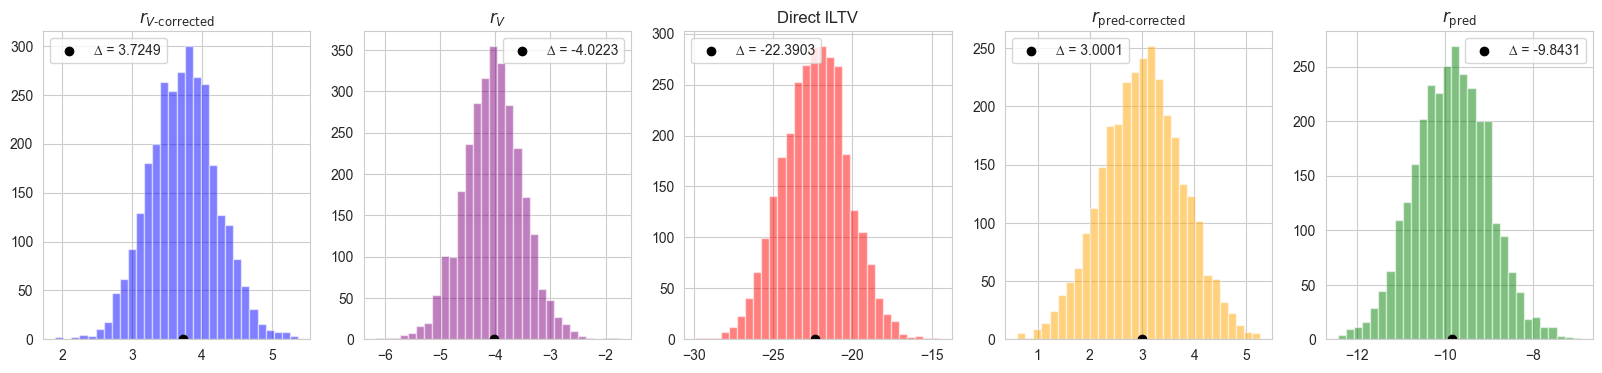

In [30]:
fig, axs = plt.subplots(1, report.shape[0], figsize=(report.shape[0] * 4, 4))


for idx, row in report.iterrows():
    sample = row['sample'].squeeze()
    axs[idx].hist(sample, bins=30, color=COLORS[idx], alpha = 0.5)
    axs[idx].scatter(row['∆'], 0, color='black', label=f"∆{row['kind']} = {row['∆']:.4f}")
    # axs[idx].set_title(row['metric'])
    axs[idx].set_title(ALIASES[idx])
    axs[idx].legend()

plt.show()

### $\Delta$, %

In [31]:
%%time

report = ab_test.get_report(
    variants=groups.keys(),
    control='control',
    metrics=METRICS_TO_REPORT,
    proportional=True,
)

report

CPU times: user 1min 59s, sys: 1min 21s, total: 3min 20s
Wall time: 6min 42s


,control,test,metric,∆,p-value,σ,ci,sample,kind
0,control,test,hat_gmv_target_uplift,3.292649,0.0,0.427113,"[2.4745462410518995, 4.143768009194805]","[[3.367456887722665, 3.093393556904126, 2.9536...",%
1,control,test,hat_gmv_target_at_T,-3.555489,0.0,0.454610,"[-4.447306383108954, -2.6526225278748115]","[[-3.5766884442279054, -3.7756790567686664, -2...",%
2,control,test,gmv_target_at_T,-15.017895,0.0,1.220023,"[-17.33635867018089, -12.572958436429305]","[[-15.638460126016934, -17.6584546033357, -13....",%
3,control,test,predict_gmv_target_uplift,2.586407,0.0,0.674454,"[1.265654179841644, 3.8994518266301936]","[[1.533550737787902, 1.2493939891653907, 2.557...",%
4,control,test,predict_gmv_target_at_T,-8.485838,0.0,0.659368,"[-9.78808208776777, -7.191741631759976]","[[-9.212031594835452, -9.290369221282155, -7.4...",%


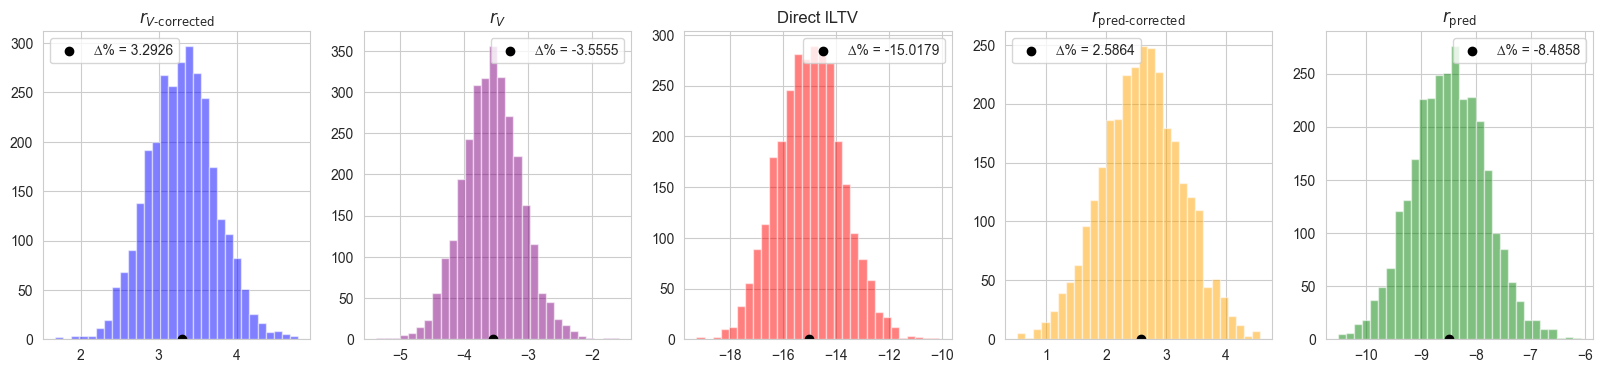

In [32]:
fig, axs = plt.subplots(1, report.shape[0], figsize=(report.shape[0] * 4, 4))


for idx, row in report.iterrows():
    sample = row['sample'].squeeze()
    axs[idx].hist(sample, bins=30, color=COLORS[idx], alpha = 0.5)
    axs[idx].scatter(row['∆'], 0, color='black', label=f"∆{row['kind']} = {row['∆']:.4f}")
    # axs[idx].set_title(row['metric'])
    axs[idx].set_title(ALIASES[idx])
    axs[idx].legend()

plt.show()